#ML workflow + setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# Load dataset
data = fetch_california_housing(as_frame=True)
df = data.frame

# Basic exploration — run each line and READ the output
print(df.shape)           # how many rows and columns?
print(df.dtypes)          # what type is each column?
print(df.isnull().sum())  # any missing values?
print(df.describe())      # min, max, mean, std for every column

(20640, 9)
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381  

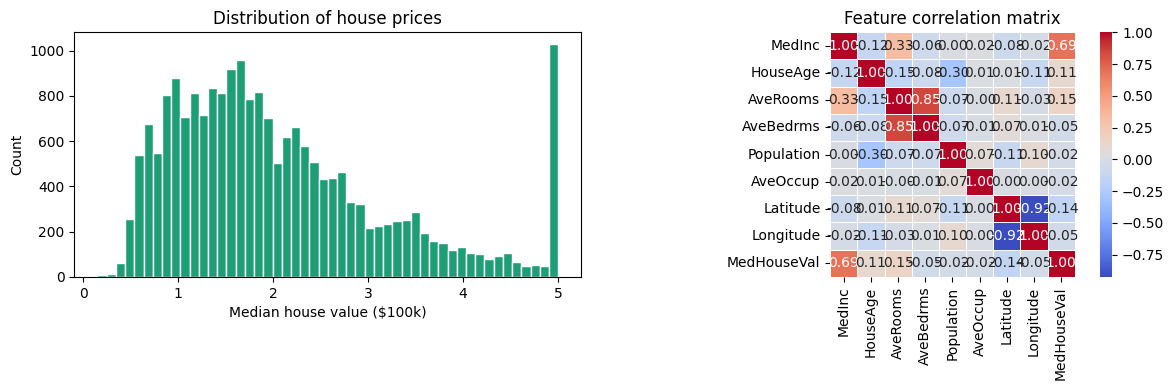

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution of house prices
axes[0].hist(df['MedHouseVal'], bins=50, color='#1D9E75', edgecolor='white')
axes[0].set_title('Distribution of house prices')
axes[0].set_xlabel('Median house value ($100k)')
axes[0].set_ylabel('Count')

# Correlation heatmap
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1], square=True, linewidths=0.5)
axes[1].set_title('Feature correlation matrix')

plt.tight_layout()
plt.show()

# Which features correlate most with house price?
print(corr['MedHouseVal'].sort_values(ascending=False))

In [ ]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)
df = data.frame

print("=== Top 5 rows ===")
print(df.head())

print("\n=== Bottom 5 rows ===")
print(df.tail())

print("\n=== Max and min house values ===")
print(f"Max:  ${df['MedHouseVal'].max() * 100_000:,.0f}")
print(f"Min:  ${df['MedHouseVal'].min() * 100_000:,.0f}")
print(f"Mean: ${df['MedHouseVal'].mean() * 100_000:,.0f}")

# How many rows are capped at the max?
capped = df[df['MedHouseVal'] == df['MedHouseVal'].max()]
print(f"\nRows capped at max value: {len(capped)} ({len(capped)/len(df)*100:.1f}%)")

=== Top 5 rows ===
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

=== Bottom 5 rows ===
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672

Slope:     0.4179
Intercept: 0.4509


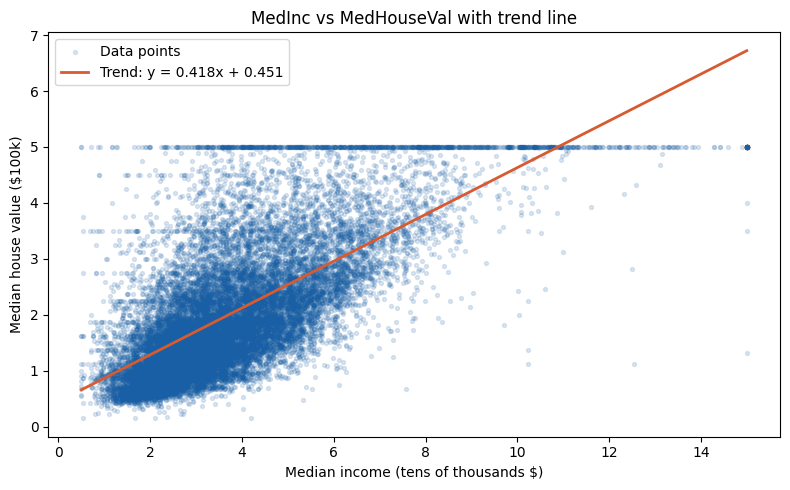

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X = df['MedInc'].values
y = df['MedHouseVal'].values

# Fit a degree-1 polynomial (straight line) — polyfit returns [slope, intercept]
coeffs = np.polyfit(X, y, deg=1)
slope, intercept = coeffs
print(f"Slope:     {slope:.4f}")
print(f"Intercept: {intercept:.4f}")

# Build the trend line
x_line = np.linspace(X.min(), X.max(), 200)
y_line = slope * x_line + intercept   # same as: np.polyval(coeffs, x_line)

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.15, s=8, color='#185FA5', label='Data points')
plt.plot(x_line, y_line, color='#D85A30', linewidth=2, label=f'Trend: y = {slope:.3f}x + {intercept:.3f}')
plt.xlabel('Median income (tens of thousands $)')
plt.ylabel('Median house value ($100k)')
plt.title('MedInc vs MedHouseVal with trend line')
plt.legend()
plt.tight_layout()
plt.show()

#OLS + scratch code

In [ ]:
import numpy as np

# Toy dataset: house sizes (sq ft) and prices ($k)
# X: size,  y: price
X_raw = np.array([1000, 1500, 2000, 2500, 3000], dtype=float)
y = np.array([200,  280,  350,  410,  480], dtype=float)

# Add bias column (column of 1s) — this learns the intercept
X = np.column_stack([np.ones(len(X_raw)), X_raw])
print("X shape:", X.shape)   # should be (5, 2)
print("y shape:", y.shape)   # should be (5,)

# Normal equation: theta = (X^T X)^-1 X^T y
theta = np.linalg.inv(X.T @ X) @ X.T @ y
print(f"\nIntercept (theta_0): {theta[0]:.2f}")
print(f"Slope (theta_1):     {theta[1]:.4f}")
print(f"\nInterpretation: for every 1 sq ft, price rises by ${theta[1]*1000:.0f}")

X shape: (5, 2)
y shape: (5,)

Intercept (theta_0): 68.00
Slope (theta_1):     0.1380

Interpretation: for every 1 sq ft, price rises by $138


In [ ]:
class LinearRegressionScratch:
    def __init__(self):
        self.theta = None   # weights including bias

    def fit(self, X, y):
        # Add bias column
        X_b = np.column_stack([np.ones(len(X)), X])
        # Normal equation
        self.theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
        return self

    def predict(self, X):
        X_b = np.column_stack([np.ones(len(X)), X])
        return X_b @ self.theta

    def score(self, X, y):
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)      # residual sum of squares
        ss_tot = np.sum((y - y.mean()) ** 2)    # total sum of squares
        return 1 - (ss_res / ss_tot)            # R²


# Test on toy data
model = LinearRegressionScratch()
model.fit(X_raw.reshape(-1, 1), y)
print("R² score:", round(model.score(X_raw.reshape(-1, 1), y), 4))
print("Predictions:", model.predict(np.array([[1200], [1800], [2200]])).round(1))

R² score: 0.9977
Predictions: [233.6 316.4 371.6]


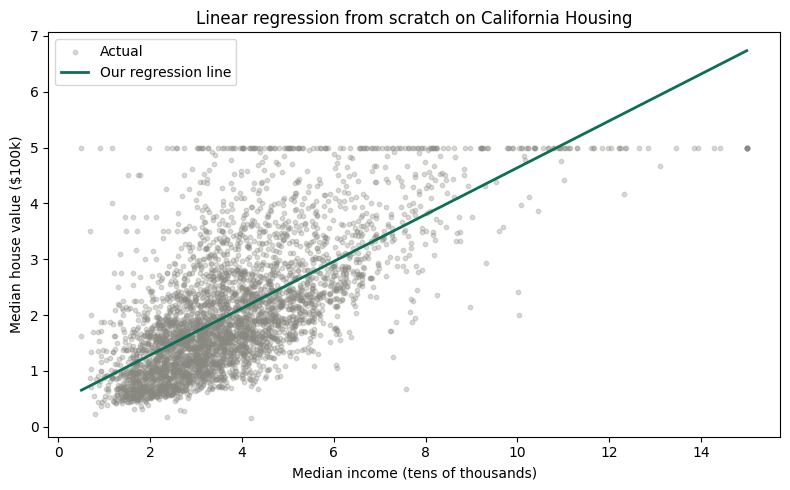

Train R²: 0.4770
Test  R²: 0.4589


In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load data — use only MedInc (income) to predict price
data = fetch_california_housing(as_frame=True)
X_cal = data.frame[['MedInc']].values.flatten()
y_cal = data.frame['MedHouseVal'].values

#Making training set and testing set using actual x-values and y-values
X_train, X_test, y_train, y_test = train_test_split(
    X_cal, y_cal, test_size=0.2, random_state=42
)

# Fit our scratch model
model_cal = LinearRegressionScratch()
model_cal.fit(X_train.reshape(-1, 1), y_train)

# Plot result
x_line = np.linspace(X_cal.min(), X_cal.max(), 100)
y_line = model_cal.predict(x_line.reshape(-1, 1))

plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, alpha=0.3, s=10, color='#888780', label='Actual')
plt.plot(x_line, y_line, color='#0F6E56', linewidth=2, label='Our regression line')
plt.xlabel('Median income (tens of thousands)')
plt.ylabel('Median house value ($100k)')
plt.title('Linear regression from scratch on California Housing')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Train R²: {model_cal.score(X_train.reshape(-1,1), y_train):.4f}")
print(f"Test  R²: {model_cal.score(X_test.reshape(-1,1),  y_test):.4f}")

Epoch    0 | MSE: 5.6297 | θ: [0.2072 0.0811]
Epoch  200 | MSE: 0.6991 | θ: [2.0677 0.7966]
Epoch  400 | MSE: 0.6991 | θ: [2.0677 0.7966]
Epoch  600 | MSE: 0.6991 | θ: [2.0677 0.7966]
Epoch  800 | MSE: 0.6991 | θ: [2.0677 0.7966]


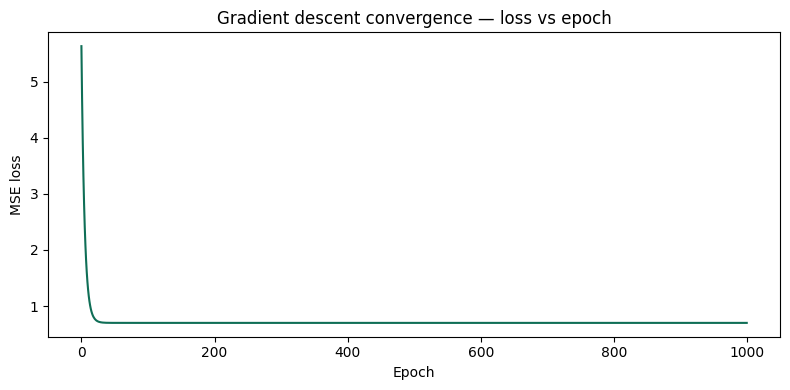


Gradient descent R²: 0.4589
Normal equation R²:  0.4589


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class LinearRegressionScratch:
    def __init__(self):
        self.theta = None
        self.loss_history = []

    def fit(self, X, y):
        X_b = np.column_stack([np.ones(len(X)), X])
        self.theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
        return self

    def fit_gd(self, X, y, lr=0.01, epochs=1000):
        n = len(y)
        X_b = np.column_stack([np.ones(n), X])
        # Initialise weights at zero
        self.theta = np.zeros(X_b.shape[1])
        self.loss_history = []

        for epoch in range(epochs):
            y_pred = X_b @ self.theta
            residuals = y_pred - y                        # (n,)
            gradient = (2 / n) * X_b.T @ residuals       # ∂L/∂θ
            self.theta -= lr * gradient                   # update rule

            loss = np.mean(residuals ** 2)                # MSE
            self.loss_history.append(loss)

            if epoch % 200 == 0:
                print(f"Epoch {epoch:4d} | MSE: {loss:.4f} | θ: {self.theta.round(4)}")

        return self

    def predict(self, X):
        X_b = np.column_stack([np.ones(len(X)), X])
        return X_b @ self.theta

    def score(self, X, y):
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        return 1 - ss_res / ss_tot


# Test on California Housing (single feature, scaled)
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = fetch_california_housing()
X_raw = data.data[:, 0].reshape(-1, 1)   # MedInc only
y = data.target

# IMPORTANT: scale features before gradient descent or it diverges
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw).flatten()

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = LinearRegressionScratch()
model.fit_gd(X_train, y_train, lr=0.05, epochs=1000)

# Plot loss convergence
plt.figure(figsize=(8, 4))
plt.plot(model.loss_history, color='#0F6E56', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.title('Gradient descent convergence — loss vs epoch')
plt.tight_layout()
plt.show()

print(f"\nGradient descent R²: {model.score(X_test, y_test):.4f}")

# Compare with normal equation (should match closely)
model_ols = LinearRegressionScratch()
model_ols.fit(X_train, y_train)
print(f"Normal equation R²:  {model_ols.score(X_test, y_test):.4f}")

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

data = fetch_california_housing(as_frame=True)
X_all = data.data.values
y = data.target.values
feature_names = data.feature_names

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# Single feature model
model_1 = LinearRegressionScratch()
model_1.fit(X_train[:, 0:1], y_train)   # MedInc only
r2_1 = model_1.score(X_test[:, 0:1], y_test)

# All 8 features model
model_8 = LinearRegressionScratch()
model_8.fit(X_train, y_train)
r2_8 = model_8.score(X_test, y_test)

print(f"R² with 1 feature  (MedInc only): {r2_1:.4f}")
print(f"R² with 8 features (all):         {r2_8:.4f}")
print(f"Improvement:                       +{(r2_8-r2_1):.4f}")

print("\nCoefficients for 8-feature model:")
for name, coef in zip(feature_names, model_8.theta[1:]):  # skip bias (theta[0])
    print(f"  {name:15s}: {coef:+.4f}")


R² with 1 feature  (MedInc only): 0.4589
R² with 8 features (all):         0.5758
Improvement:                       +0.1169

Coefficients for 8-feature model:
  MedInc         : +0.4487
  HouseAge       : +0.0097
  AveRooms       : -0.1233
  AveBedrms      : +0.7831
  Population     : -0.0000
  AveOccup       : -0.0035
  Latitude       : -0.4198
  Longitude      : -0.4337


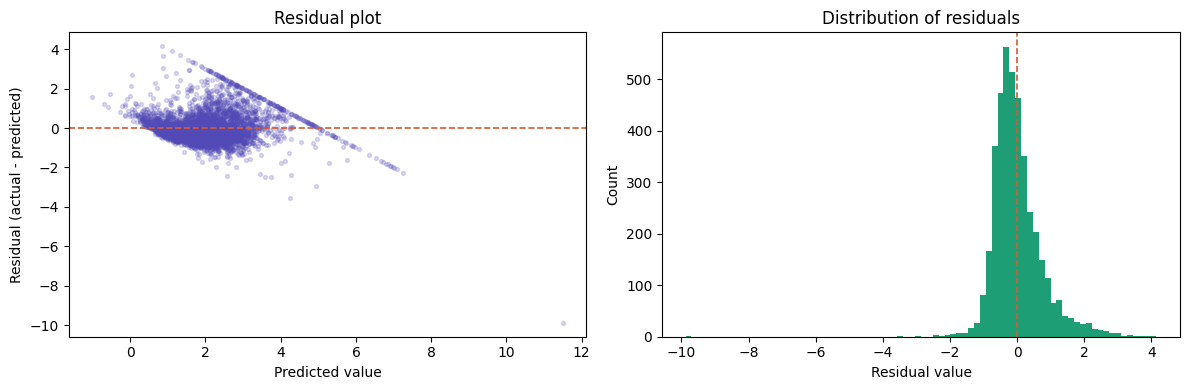

Mean of residuals:   0.003479  (should be ~0)
Std of residuals:    0.7456
Max positive error:  +4.1484
Max negative error:  -9.8753


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Use the 8-feature model from Ex 3
y_pred_test = model_8.predict(X_test)
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residuals vs predicted values
axes[0].scatter(y_pred_test, residuals, alpha=0.2, s=8, color='#534AB7')
axes[0].axhline(0, color='#D85A30', linewidth=1.2, linestyle='--')
axes[0].set_xlabel('Predicted value')
axes[0].set_ylabel('Residual (actual - predicted)')
axes[0].set_title('Residual plot')

# Histogram of residuals
axes[1].hist(residuals, bins=80, color='#1D9E75', edgecolor='none')
axes[1].axvline(0, color='#D85A30', linewidth=1.2, linestyle='--')
axes[1].set_xlabel('Residual value')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of residuals')

plt.tight_layout()
plt.show()

print(f"Mean of residuals:   {residuals.mean():.6f}  (should be ~0)")
print(f"Std of residuals:    {residuals.std():.4f}")
print(f"Max positive error:  +{residuals.max():.4f}")
print(f"Max negative error:  {residuals.min():.4f}")

 # fit sklearn on all 8 features

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

data = fetch_california_housing(as_frame=True)
X = data.data        # all 8 features
y = data.target      # median house value

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Intercept:", round(model.intercept_, 4))
print("\nCoefficients:")
for name, coef in zip(data.feature_names, model.coef_):
    print(f"  {name:15s}: {coef:+.4f}")

Intercept: -37.0233

Coefficients:
  MedInc         : +0.4487
  HouseAge       : +0.0097
  AveRooms       : -0.1233
  AveBedrms      : +0.7831
  Population     : -0.0000
  AveOccup       : -0.0035
  Latitude       : -0.4198
  Longitude      : -0.4337


In [ ]:
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("=" * 45)
print(f"R²   = {r2:.4f}  → model explains {r2*100:.1f}% of variance")
print(f"MAE  = {mae:.4f}  → avg error = ${mae*100_000:,.0f}")
print(f"MSE  = {mse:.4f}  → penalises large errors more")
print(f"RMSE = {rmse:.4f}  → same unit as target, like MAE")
print("=" * 45)
print(f"\nAverage house value in test set: ${y_test.mean()*100_000:,.0f}")
print(f"Our avg prediction error:        ${mae*100_000:,.0f}")
print(f"Error as % of average:           {mae/y_test.mean()*100:.1f}%")

R²   = 0.5758  → model explains 57.6% of variance
MAE  = 0.5332  → avg error = $53,320
MSE  = 0.5559  → penalises large errors more
RMSE = 0.7456  → same unit as target, like MAE

Average house value in test set: $205,500
Our avg prediction error:        $53,320
Error as % of average:           25.9%


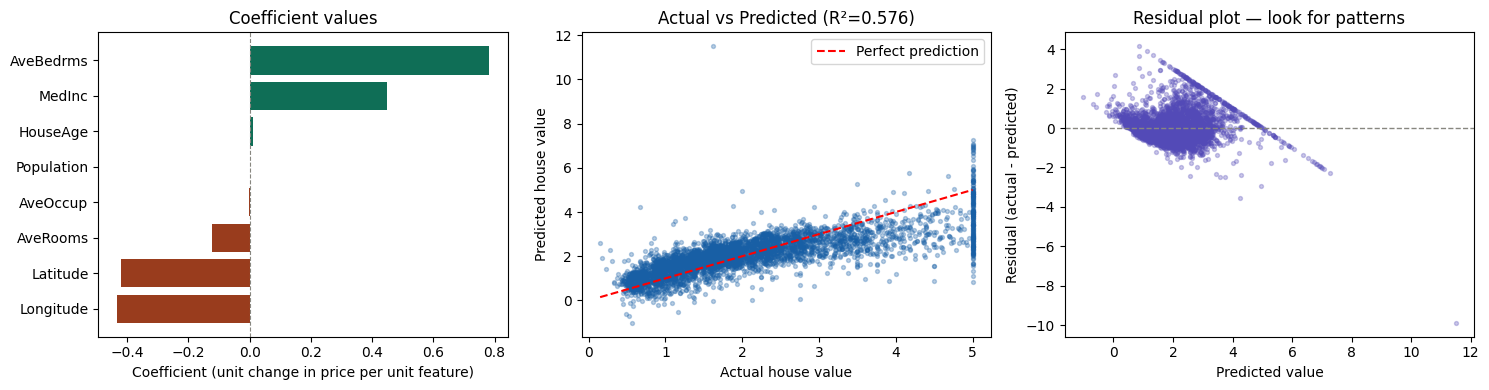

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Plot 1: coefficient bar chart ---
coef_df = pd.Series(model.coef_, index=data.feature_names).sort_values()
colors = ['#993C1D' if c < 0 else '#0F6E56' for c in coef_df]
axes[0].barh(coef_df.index, coef_df.values, color=colors)
axes[0].axvline(0, color='#888780', linewidth=0.8, linestyle='--')
axes[0].set_title('Coefficient values')
axes[0].set_xlabel('Coefficient (unit change in price per unit feature)')

# --- Plot 2: actual vs predicted ---
axes[1].scatter(y_test, y_pred, alpha=0.3, s=8, color='#185FA5')
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=1.5, label='Perfect prediction')
axes[1].set_xlabel('Actual house value')
axes[1].set_ylabel('Predicted house value')
axes[1].set_title(f'Actual vs Predicted (R²={r2:.3f})')
axes[1].legend()

# --- Plot 3: residual plot ---
residuals = y_test - y_pred
axes[2].scatter(y_pred, residuals, alpha=0.3, s=8, color='#534AB7')
axes[2].axhline(0, color='#888780', linewidth=1, linestyle='--')
axes[2].set_xlabel('Predicted value')
axes[2].set_ylabel('Residual (actual - predicted)')
axes[2].set_title('Residual plot — look for patterns')

plt.tight_layout()
plt.show()

# KEY QUESTION: What do you see in the residual plot?
# A random scatter = good fit. A funnel or curve = model is missing something.

- Ex 1
Metric quiz: Your model has MAE = 0.53 and RMSE = 0.73 (in $100k). The RMSE is always ≥ MAE. Why? What does the gap between them tell you about your errors?
- Ex 2
Remove one feature at a time — refit the model without each column. Which single feature removal hurts R² the most? Which column can you remove with almost no cost?
- Ex 3
Stakeholder explanation: Write 3 sentences explaining the model results to someone with no ML knowledge. State the error in dollars, not in R² units.
- Ex 4
Negative coefficients: The Latitude coefficient should be negative. Why does moving further north (higher latitude) predict a lower house price in California? Does this make real-world sense?

In [ ]:
import numpy as np

# Demonstrate with two scenarios
errors_uniform = np.array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5])   # all equal
errors_mixed   = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 2.5])    # one big outlier

for name, errors in [("Uniform errors", errors_uniform),
                     ("One outlier",    errors_mixed)]:
    mae  = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(errors ** 2))
    gap  = rmse - mae
    print(f"{name}:")
    print(f"  MAE  = {mae:.4f}")
    print(f"  RMSE = {rmse:.4f}")
    print(f"  Gap  = {gap:.4f}  ({'large — outlier present' if gap > 0.1 else 'small — errors similar'})")
    print()

# The actual meaning of your numbers
mae_val  = 0.53
rmse_val = 0.73
print(f"Your model: MAE=${mae_val*100_000:,.0f}  RMSE=${rmse_val*100_000:,.0f}")
print(f"Gap = ${(rmse_val - mae_val)*100_000:,.0f}")
print("\nConclusion: gap of $20,000 means your model makes occasional")
print("large errors (outlier predictions), not just consistent small ones.")

Uniform errors:
  MAE  = 0.5000
  RMSE = 0.5000
  Gap  = 0.0000  (small — errors similar)

One outlier:
  MAE  = 0.5000
  RMSE = 1.0247
  Gap  = 0.5247  (large — outlier present)

Your model: MAE=$53,000  RMSE=$73,000
Gap = $20,000

Conclusion: gap of $20,000 means your model makes occasional
large errors (outlier predictions), not just consistent small ones.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

data = fetch_california_housing(as_frame=True)
X = data.data
y = data.target
feature_names = data.feature_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Baseline with all 8 features
base_model = LinearRegression().fit(X_train, y_train)
base_r2 = r2_score(y_test, base_model.predict(X_test))
print(f"Baseline R² (all 8 features): {base_r2:.4f}\n")

results = []
for col in feature_names:
    X_train_drop = X_train.drop(columns=[col])
    X_test_drop  = X_test.drop(columns=[col])
    model = LinearRegression().fit(X_train_drop, y_train)
    r2 = r2_score(y_test, model.predict(X_test_drop))
    drop = base_r2 - r2
    results.append({'feature': col, 'r2_without': r2, 'r2_drop': drop})
    print(f"Without {col:15s}: R²={r2:.4f}  (drop = {drop:+.4f})")

results_df = pd.DataFrame(results).sort_values('r2_drop', ascending=False)
print(f"\nMost important feature:  {results_df.iloc[0]['feature']}")
print(f"Least important feature: {results_df.iloc[-1]['feature']}")

Baseline R² (all 8 features): 0.5758

Without MedInc         : R²=0.4063  (drop = +0.1695)
Without HouseAge       : R²=0.5700  (drop = +0.0058)
Without AveRooms       : R²=0.5799  (drop = -0.0041)
Without AveBedrms      : R²=0.5823  (drop = -0.0065)
Without Population     : R²=0.5757  (drop = +0.0000)
Without AveOccup       : R²=0.5751  (drop = +0.0007)
Without Latitude       : R²=0.5103  (drop = +0.0655)
Without Longitude      : R²=0.5139  (drop = +0.0619)

Most important feature:  MedInc
Least important feature: AveBedrms
